# Predicting Student Health Risk（Kaggle Playground S6E7）

3クラス分類（at-risk / unhealthy / fit）、評価指標：Balanced Accuracy

## 1. ライブラリ読み込み

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
warnings.filterwarnings("ignore")

## 2. データ読み込み・確認

In [57]:
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

print(df_train.shape)
print("")
print(df_train.head())
print("")
print(df_train.isnull().sum())  # 全列の欠損値の数
print("")
print(df_train['health_condition'].value_counts())  # ターゲットの分布

(690088, 15)

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   
3   3        unhealthy            4.70        77.2  23.13   
4   4          at-risk            7.23        73.4  28.44   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0               2174.0      1326.0               19.8          1.86       veg   
1               1966.0      9891.0               49.9          1.26   non-veg   
2               2688.0     14216.0               38.1          1.60       veg   
3               2630.0      7174.0               59.9          2.02       veg   
4               2560.0      6584.0               46.0          2.25       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  
0         high       average               sedentary 

In [58]:
print(df_test.head())

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088            5.35        64.9  23.48               2745.0     14167.0   
1  690089             NaN        83.1  22.42               1773.0      6801.0   
2  690090            6.68        59.7  24.14               3040.0     13250.0   
3  690091            7.13        78.5  26.26               2494.0      6331.0   
4  690092            5.49        77.7  23.29               1828.0     13894.0   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0               59.5          1.86       veg         high          poor   
1               24.5          2.40  balanced         high          poor   
2               48.5          2.76  balanced       medium          poor   
3               56.9          2.34       veg          low          good   
4               39.4          2.45       veg         high       average   

  physical_activity_level smoking_alcohol gender  
0          

## 3. カテゴリ変数の確認

'stress_level', 'sleep_quality', 'diet_type', 'smoking_alcohol', 'gender' のデータの種類を見る

In [59]:
for col in ['stress_level','sleep_quality','diet_type','smoking_alcohol','gender']:
    print(f"\n{col}:")
    print(df_train[col].unique())


stress_level:
['high' 'low' nan 'medium']

sleep_quality:
['average' 'poor' nan 'good']

diet_type:
['veg' 'non-veg' 'balanced' nan]

smoking_alcohol:
['yes' 'occasional' nan 'no']

gender:
['female' 'other' 'male' nan]


## 4. 前処理

- 順序ありカテゴリ（stress_level, sleep_quality, physical_activity_level）→ map()で数値化 → 最頻値で欠損補完
- 順序なしカテゴリ（diet_type, smoking_alcohol, gender）→ 欠損値を'unknown'で補完した上でOne-Hot Encoding
  （順序なしカテゴリをLabelEncoderで数値化すると、本来存在しない大小関係をモデルに学習させてしまうため）

In [60]:
# 順序ありカテゴリ
stress_map = {'low': 0, 'medium': 1, 'high': 2}
sleep_map = {'poor': 0, 'average': 1, 'good': 2}
activity_map = {'sedentary': 0, 'moderate': 1, 'active': 2}

for df in [df_train, df_test]:
    df['stress_level'] = df['stress_level'].map(stress_map)
    df['sleep_quality'] = df['sleep_quality'].map(sleep_map)
    df['physical_activity_level'] = df['physical_activity_level'].map(activity_map)

stress_mode = df_train['stress_level'].mode()[0]
sleep_mode = df_train['sleep_quality'].mode()[0]
activity_mode = df_train['physical_activity_level'].mode()[0]

df_train['stress_level'] = df_train['stress_level'].fillna(stress_mode)
df_test['stress_level'] = df_test['stress_level'].fillna(stress_mode)

df_train['sleep_quality'] = df_train['sleep_quality'].fillna(sleep_mode)
df_test['sleep_quality'] = df_test['sleep_quality'].fillna(sleep_mode)

df_train['physical_activity_level'] = df_train['physical_activity_level'].fillna(activity_mode)
df_test['physical_activity_level'] = df_test['physical_activity_level'].fillna(activity_mode)

# 順序なしカテゴリ：欠損値をunknownで埋めてからOne-Hot Encoding
categorical_cols = ['diet_type', 'smoking_alcohol', 'gender']

for col in categorical_cols:
    df_train[col] = df_train[col].fillna('unknown')
    df_test[col] = df_test[col].fillna('unknown')

df_train = pd.get_dummies(df_train, columns=categorical_cols)
df_test = pd.get_dummies(df_test, columns=categorical_cols)

# train/testでカラムがズレないように揃える
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

print(df_train.columns.tolist())

['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'diet_type_balanced', 'diet_type_non-veg', 'diet_type_unknown', 'diet_type_veg', 'smoking_alcohol_no', 'smoking_alcohol_occasional', 'smoking_alcohol_unknown', 'smoking_alcohol_yes', 'gender_female', 'gender_male', 'gender_other', 'gender_unknown']


**メモ：`.map()`について**

.map() は、辞書(dict)を使って列の値を1対1で置き換えるpandasの処理。

```
stress_map = {'low': 0, 'medium': 1, 'high': 2}
df['stress_level'] = df['stress_level'].map(stress_map)
```

| 元の値 | 変換後 |
|---|---|
| 'low' | 0 |
| 'medium' | 1 |
| 'high' | 2 |

## 5. 特徴量・ターゲットの定義

In [61]:
features = ['sleep_duration', 'heart_rate', 'bmi',
            'calorie_expenditure', 'step_count',
            'exercise_duration', 'water_intake',
            'stress_level', 'sleep_quality',
            'physical_activity_level',
            'diet_type_balanced', 'diet_type_non-veg', 'diet_type_veg', 'diet_type_unknown',
            'smoking_alcohol_no', 'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'smoking_alcohol_unknown',
            'gender_female', 'gender_male', 'gender_other', 'gender_unknown']

X = df_train[features]
y = df_train['health_condition']

# ターゲットのラベルエンコード
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
print(le_y.classes_)  # どの数字が何のクラスか確認

['at-risk' 'fit' 'unhealthy']


## 6. 特徴量同士の相関を見る

`step_count` / `exercise_duration` / `physical_activity_level` が互いに0.64前後の相関あり。

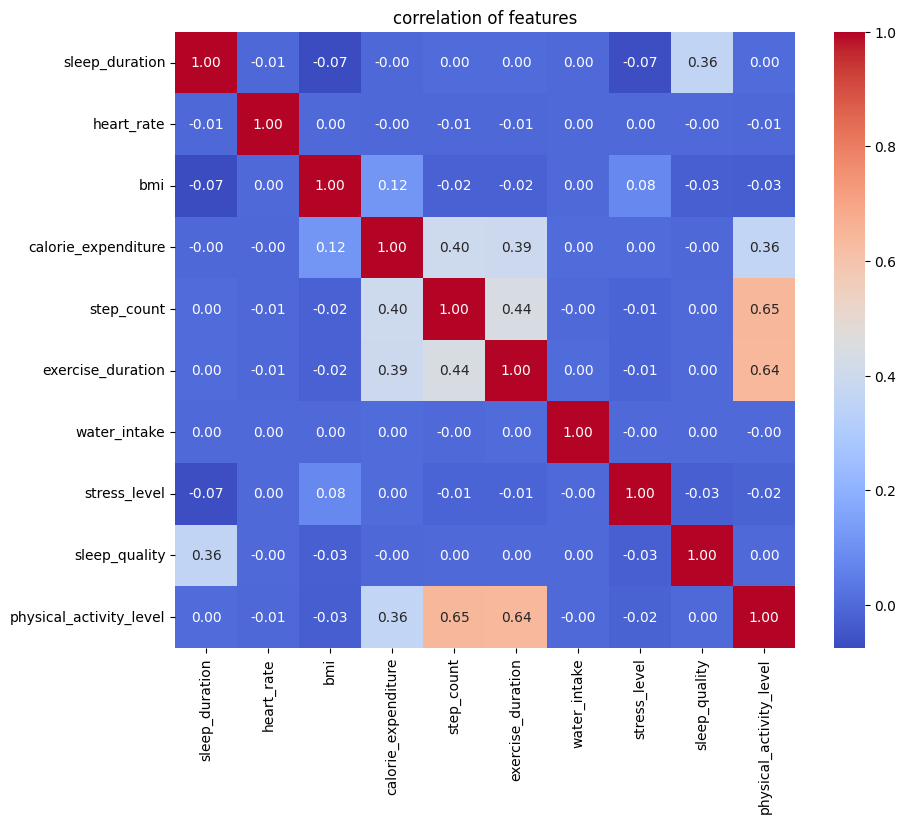

In [62]:
num_cols = ['sleep_duration', 'heart_rate', 'bmi',
            'calorie_expenditure', 'step_count',
            'exercise_duration', 'water_intake',
            'stress_level', 'sleep_quality', 'physical_activity_level']

plt.figure(figsize=(10, 8))
sns.heatmap(df_train[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation of features')
plt.show()

## 7. ベースライン（LightGBM, class_weight='balanced'）

クラス不均衡（at-risk 86% / unhealthy 8% / fit 6%）への対策として class_weight='balanced' を使用。

| 設定 | Balanced Accuracy(CV平均) |
|---|---|
| デフォルト（対策なし） | 0.85665 |
| class_weight='balanced' | 0.90975 |
| ↑ + One-Hot(unknown列含む) | **0.90979** |

In [63]:
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) #時間短縮版

scores = []
for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores.append(score)

print(scores)
print(f"平均: {np.mean(scores):.5f}")

[np.float64(0.9101267040481936), np.float64(0.9102488984535425), np.float64(0.9080630581066137)]
平均: 0.90948


In [64]:
# import optuna

# def objective(trial):
#     params = {
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'random_state': 42,
#         'verbose': -1,
#         'class_weight': 'balanced',
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
#     }
    
#     scores = []
#     for train_idx, val_idx in skf.split(X, y_encoded):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
        
#         model = lgb.LGBMClassifier(**params)
#         model.fit(X_tr, y_tr)
        
#         pred = model.predict(X_val)
#         score = balanced_accuracy_score(y_val, pred)
#         scores.append(score)
    
#     return np.mean(scores)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20,show_progress_bar=True)

# print("Best score:", study.best_value)
# print("Best params:", study.best_params)

**Optuna 1回目（reg_alpha/reg_lambdaなし）**

Best score: 0.910944307058184
Best params: {'num_leaves': 44, 'learning_rate': 0.13277468944236256, 'max_depth': 12, 'min_child_samples': 65, 'subsample': 0.7837267840394909, 'colsample_bytree': 0.510053028762963}

**Optuna 2回目（reg_alpha/reg_lambda追加）**

Best score: 0.9101477649827593
Best params: {'num_leaves': 82, 'learning_rate': 0.1160231343435626, 'max_depth': 12, 'min_child_samples': 6, 'subsample': 0.5697403706408114, 'colsample_bytree': 0.5021621039648005, 'reg_alpha': 1.4920760742438395e-05, 'reg_lambda': 1.1143520714867163e-06}

→ 2回目を正式採用（下のセルで5分割検証済み、CV平均0.90989）


### **Optuna最適化後（LightGBM, class_weight='balanced'）（採用）**

In [65]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 標準版に戻す

params = {
 'num_leaves': 82,
 'learning_rate': 0.1160231343435626, 'max_depth': 12,
 'min_child_samples': 6, 'subsample': 0.5697403706408114,
 'colsample_bytree': 0.5021621039648005,
 'reg_alpha': 1.4920760742438395e-05,
 'reg_lambda': 1.1143520714867163e-06,
 'random_state': 42,
 'verbose': -1,
 'class_weight': 'balanced'
}

scores = []
for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)
    scores.append(balanced_accuracy_score(y_val, pred))

print(scores)
print(f"平均: {np.mean(scores):.5f}")

[np.float64(0.9105573204234645), np.float64(0.910935417481921), np.float64(0.9105856231367097), np.float64(0.9093005386664478), np.float64(0.9080893621250494)]
平均: 0.90989


## 8. ベースライン（XGBClassifier, class_weight='balanced'）

クラス不均衡（at-risk 86% / unhealthy 8% / fit 6%）への対策として class_weight='balanced' の代わりに sample_weight（compute_sample_weight）を使用。


In [66]:
from sklearn.utils.class_weight import compute_sample_weight

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 時間短縮版

scores = []
for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)

    model = xgb.XGBClassifier(
        random_state=42,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss'
    )
    model.fit(X_tr, y_tr, sample_weight=sw_tr)

    pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores.append(score)

print(scores)
print(f"平均: {np.mean(scores):.5f}")

[np.float64(0.9096248885807916), np.float64(0.90999968023341), np.float64(0.9101664482198331), np.float64(0.9075945152126242), np.float64(0.9069121280795747)]
平均: 0.90886


### Optuna最適化（XGBoost）


In [67]:
# def objective(trial):
#     params = {
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'n_estimators': trial.suggest_int('n_estimators', 50, 300),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'random_state': 42,
#         'objective': 'multi:softmax',
#         'num_class': 3,
#         'eval_metric': 'mlogloss'
#     }

#     scores = []
#     for train_idx, val_idx in skf.split(X, y_encoded):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

#         sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)

#         model = xgb.XGBClassifier(**params)
#         model.fit(X_tr, y_tr, sample_weight=sw_tr)

#         pred = model.predict(X_val)
#         score = balanced_accuracy_score(y_val, pred)
#         scores.append(score)

#     return np.mean(scores)

# study_xgb = optuna.create_study(direction='maximize')
# study_xgb.optimize(objective, n_trials=20, show_progress_bar=True)

# print("Best score:", study_xgb.best_value)
# print("Best params:", study_xgb.best_params)

In [68]:
# Optuna最適化後（採用）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 標準版に戻す

params = {
'max_depth': 5,
'learning_rate': 0.11566626538950761, 
'n_estimators': 172, 
'subsample': 0.9926148791938509, 
'colsample_bytree': 0.6512981021180146, 
'reg_alpha': 0.001196537618265404, 
'reg_lambda': 8.934080294103993

}

scores = []
for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)

    model = xgb.XGBClassifier(**params,
        random_state=42,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss')
    model.fit(X_tr, y_tr, sample_weight=sw_tr)

    pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores.append(score)

print(scores)
print(f"平均: {np.mean(scores):.5f}")

[np.float64(0.9111651169224277), np.float64(0.9107195588336884), np.float64(0.9104895992585925), np.float64(0.9106569816802326), np.float64(0.9091679799635889)]
平均: 0.91044


## 9. アンサンブル（LightGBM + XGBoost, 重み付き平均）

oofで重みを0.0〜1.0まで探索した結果、XGBoost=0.6 / LightGBM=0.4 が最良（CV平均 0.91068）。


In [69]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_params = {
    'num_leaves': 82, 'learning_rate': 0.1160231343435626, 'max_depth': 12,
    'min_child_samples': 6, 'subsample': 0.5697403706408114,
    'colsample_bytree': 0.5021621039648005,
    'reg_alpha': 1.4920760742438395e-05, 'reg_lambda': 1.1143520714867163e-06,
    'random_state': 42, 'verbose': -1, 'class_weight': 'balanced'
}

xgb_params = {
    'max_depth': 5, 'learning_rate': 0.11566626538950761, 'n_estimators': 172,
    'subsample': 0.9926148791938509, 'colsample_bytree': 0.6512981021180146,
    'reg_alpha': 0.001196537618265404, 'reg_lambda': 8.934080294103993,
    'random_state': 42, 'objective': 'multi:softmax', 'num_class': 3,
    'eval_metric': 'mlogloss'
}

oof_lgb = np.zeros((len(X), 3))
oof_xgb = np.zeros((len(X), 3))

for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
    sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)

    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr, y_tr)
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)

    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)

# 重みを0.0〜1.0まで0.1刻みで試す
best_score = 0
best_w = 0
for w in np.arange(0.0, 1.05, 0.1):
    blended = w * oof_xgb + (1 - w) * oof_lgb
    pred = np.argmax(blended, axis=1)
    score = balanced_accuracy_score(y_encoded, pred)
    print(f"XGBoost weight={w:.1f} → {score:.5f}")
    if score > best_score:
        best_score = score
        best_w = w

print(f"\nベスト重み: XGBoost={best_w:.1f}, LightGBM={1-best_w:.1f}")
print(f"ベストスコア: {best_score:.5f}")

XGBoost weight=0.0 → 0.90989
XGBoost weight=0.1 → 0.91008
XGBoost weight=0.2 → 0.91035
XGBoost weight=0.3 → 0.91048
XGBoost weight=0.4 → 0.91058
XGBoost weight=0.5 → 0.91062
XGBoost weight=0.6 → 0.91068
XGBoost weight=0.7 → 0.91045
XGBoost weight=0.8 → 0.91041
XGBoost weight=0.9 → 0.91036
XGBoost weight=1.0 → 0.91044

ベスト重み: XGBoost=0.6, LightGBM=0.4
ベストスコア: 0.91068


## 10. 特徴量重要度


                       feature  importance
0               sleep_duration        1670
2                          bmi        1552
6                 water_intake         930
4                   step_count         791
1                   heart_rate         789
5            exercise_duration         768
3          calorie_expenditure         665
7                 stress_level         587
9      physical_activity_level         292
16         smoking_alcohol_yes         227
8                sleep_quality         202
14          smoking_alcohol_no         156
15  smoking_alcohol_occasional          81
19                 gender_male          55
17     smoking_alcohol_unknown          39
11           diet_type_non-veg          37
20                gender_other          36
12               diet_type_veg          35
10          diet_type_balanced          29
18               gender_female          25
13           diet_type_unknown          18
21              gender_unknown          16


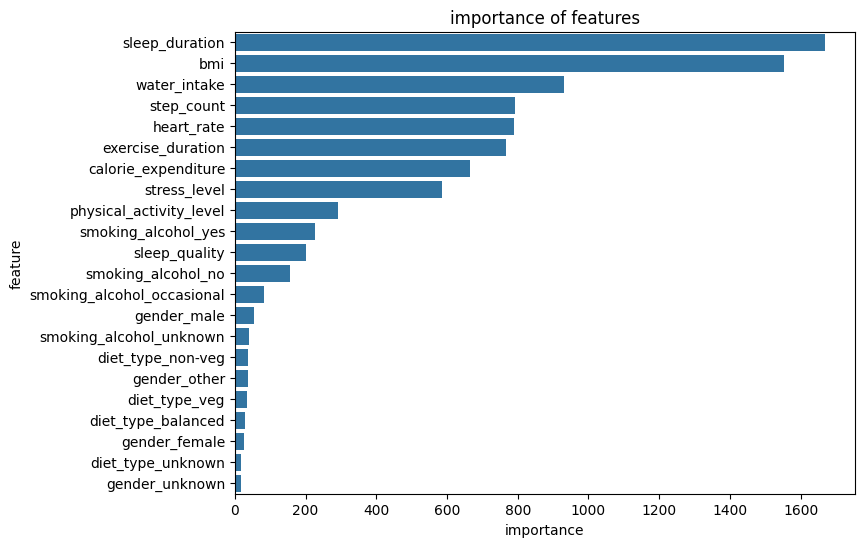

In [70]:
model = lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
model.fit(X, y_encoded)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('importance of features')
plt.show()

## 11. 検証：physical_activity_level は削っていいか？

**仮説**：step_count / exercise_duration / physical_activity_level は相関が高く（0.64前後）、physical_activity_level の重要度は最下位クラス（319）のため、削っても性能に影響しないのではないか。

**結果**：

| features | Balanced Accuracy(CV平均) |
|---|---|
| 3列とも残す（採用） | 0.90979 |
| physical_activity_level を削除 | 0.89460（-0.0152） |

**結論**：相関が高くても情報は完全には重複していなかった。step_count/exercise_duration が「当日の行動量」、physical_activity_level が「普段の生活パターンの分類」と、それぞれ独自の情報を持っていたと考えられる。→ **3列とも残す方針を採用。**

In [71]:
# 検証用（features_v2として別名で作成、Xは変更しない）
features_v2 = [f for f in features if f != 'physical_activity_level']
X_v2 = df_train[features_v2]

scores_v2 = []
for train_idx, val_idx in skf.split(X_v2, y_encoded):
    X_tr, X_val = X_v2.iloc[train_idx], X_v2.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores_v2.append(score)

print(scores_v2)
print(f"平均: {np.mean(scores_v2):.5f}")

[np.float64(0.8949653519676076), np.float64(0.8956742842301901), np.float64(0.8947337434732375), np.float64(0.8936389684696856), np.float64(0.8939677956077351)]
平均: 0.89460


## 12. 最終モデル学習・submitファイル作成（アンサンブル版）


In [72]:
# 全学習データで最終モデルを学習
final_lgb = lgb.LGBMClassifier(**lgb_params)
final_lgb.fit(X, y_encoded)

sw_full = compute_sample_weight(class_weight='balanced', y=y_encoded)
final_xgb = xgb.XGBClassifier(**xgb_params)
final_xgb.fit(X, y_encoded, sample_weight=sw_full)

# test.csvに対して予測確率を出す
X_test = df_test[features]
proba_lgb = final_lgb.predict_proba(X_test)
proba_xgb = final_xgb.predict_proba(X_test)

# ベスト重み(XGBoost=0.6, LightGBM=0.4)で混ぜる
best_w = 0.6
blended_test = best_w * proba_xgb + (1 - best_w) * proba_lgb
pred_test = np.argmax(blended_test, axis=1)

# 数字からラベルに戻す
pred_labels = le_y.inverse_transform(pred_test)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': pred_labels
})

print(submission.head())
print(submission['health_condition'].value_counts())

submission.to_csv('submission.csv', index=False)

       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
health_condition
at-risk      224912
unhealthy     40467
fit           30374
Name: count, dtype: int64


## 13. submitスコア

| モデル | CV平均 | submitスコア | 差 |
|---|---|---|---|
| LightGBM単体（Optuna後） | 0.90989 | 0.90475 | -0.0050 |
| LightGBM + XGBoost アンサンブル（0.4:0.6） | **0.91068** | **0.90629** | -0.0044 |

LATEST / BEST SCORE: **0.90629**（アンサンブルが現時点の最高記録）
